# Loading the Constitutions

In [ ]:
pip install gensim

In [ ]:
import pandas as pd
import gensim
import spacy
from google.colab import files

In [ ]:
from gensim import corpora

In [ ]:
const = files.upload()
# 1. Load the data
df = pd.read_csv(list(const.keys())[0])

# 2. Ensure the text column is treated as a string (sometimes CSVs read text weirdly)
df['Text'] = df['Text'].astype(str)

# 3. Verify it loaded
print(df.head())
print(f"Loaded {len(df)} documents.")



Saving clean_constitutions.csv to clean_constitutions (1).csv
     State  Year Region         Label  \
0  Alabama  1819  South  Alabama 1819   
1  Alabama  1861  South  Alabama 1861   
2  Alabama  1865  South  Alabama 1865   
3  Alabama  1868  South  Alabama 1868   
4  Alabama  1875  South  Alabama 1875   

                                                Text  \
0  This is ready to go\n\nJW 12.29.01            ...   
1  This is ready to go\n\nJW 12/29/01\n          ...   
2  This is ready to go.\n\nJW 12.29.01\n\n       ...   
3  This one is ready to go.\nJW 12.29.01         ...   
4  This constitution is ready to go.\nJW 12.29.01...   

          Original_Filename                                         Clean_Text  
0  AL1819_final_parts_0.txt  ready JW 12.29.01 CONSTITUTION 1819 text CSTAR...  
1  AL1861_final_parts_0.txt  ready JW 12/29/01 CSTART AL 1/7/1861 9/12/1865...  
2  AL1865_final_parts_0.txt  ready JW 12.29.01 CONSTITUTION 1865 text CSTAR...  
3  AL1868_final_parts_0.txt  r

# Latent Dirichlet Allocation

In [ ]:
import re

# 1. Load SpaCy
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])
nlp.max_length = 2000000  # Increase max_length to handle longer documents

# 2. Create Custom Stop Words List
# Initialize with SpaCy's default stop words
custom_stop_word_set = set(nlp.Defaults.stop_words)

all_states = [
    'alabama', 'alaska', 'arizona', 'arkansas', 'california', 'colorado',
    'connecticut', 'delaware', 'florida', 'georgia', 'hawaii', 'idaho',
    'illinois', 'indiana', 'iowa', 'kansas', 'kentucky', 'louisiana',
    'maine', 'maryland', 'massachusetts', 'michigan', 'minnesota',
    'mississippi', 'missouri', 'montana', 'nebraska', 'nevada',
    'new hampshire', 'new jersey', 'new mexico', 'new york',
    'north carolina', 'north dakota', 'ohio', 'oklahoma', 'oregon',
    'pennsylvania', 'rhode island', 'south carolina', 'south dakota',
    'tennessee', 'texas', 'utah', 'vermont', 'virginia', 'washington',
    'west virginia', 'wisconsin', 'wyoming'
]

# Add individual words from state names to the custom stop word set
for state in all_states:
    for word in state.split(): # Split multi-word state names into individual words
        custom_stop_word_set.add(word.lower())

# 3. Updated Cleaning Function
def spacy_lemmatize_strong(text):
    doc = nlp(text)

    return [token.lemma_.lower() for token in doc
            if token.lemma_.lower() not in custom_stop_word_set # Directly check against our comprehensive set
            and not token.is_punct    # Removes . , " etc.
            and not token.is_space    # Removes "  " and newlines
            and not token.like_num    # Removes 1776, 2024, 1, 2, 3
            and len(token.text) > 2]  # Removes short junk like "a", "an"

print("Re-processing documents with strict cleaning...")

# 4. Re-Process
processed_docs = df['Text'].apply(spacy_lemmatize_strong).tolist()

# 5. Re-Create Dictionary and Corpus
dictionary = corpora.Dictionary(processed_docs)
dictionary.filter_extremes(no_below=2, no_above=0.5) # Filter noise again
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

# 6. Re-Train Model
lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=15
)

# 7. Print New Topics
print("\n--- New Cleaned Topics ---")
for topic_id, topic_content in lda_model.print_topics(num_words=10):
    print(f"\nTopic #{topic_id+1}")
    print(topic_content)

Re-processing documents with strict cleaning...

--- New Cleaned Topics ---

Topic #1
0.020*"nov." + 0.015*"subsection" + 0.013*"amended" + 0.013*"homestead" + 0.008*"veterans" + 0.008*"range" + 0.008*"valorem" + 0.007*"subdivision" + 0.006*"intersection" + 0.006*"retirement"

Topic #2
0.021*"indebtedness" + 0.019*"municipality" + 0.011*"pledge" + 0.011*"fire" + 0.009*"facility" + 0.009*"effective" + 0.009*"taxable" + 0.008*"issuance" + 0.007*"text" + 0.007*"area"

Topic #3
0.012*"effective" + 0.012*"indebtedness" + 0.009*"village" + 0.008*"subdivision" + 0.006*"street" + 0.006*"railroad" + 0.006*"initiative" + 0.005*"fiscal" + 0.005*"art" + 0.005*"centum"

Topic #4
0.018*"baltimore" + 0.015*"effective" + 0.008*"valuation" + 0.008*"council" + 0.007*"fiscal" + 0.007*"subsection" + 0.006*"home" + 0.006*"recall" + 0.006*"chapter" + 0.006*"percent"

Topic #5
0.022*"art" + 0.014*"effective" + 0.010*"commonwealth" + 0.009*"parish" + 0.008*"superior" + 0.008*"council" + 0.005*"paragraph" + 0.

## We want to determine the optimal number of topics using coherence scores.

Training model with 2 topics...
   Coherence Score: 0.3837
Training model with 3 topics...
   Coherence Score: 0.4192
Training model with 4 topics...
   Coherence Score: 0.4037
Training model with 5 topics...
   Coherence Score: 0.3508
Training model with 6 topics...
   Coherence Score: 0.3566
Training model with 7 topics...
   Coherence Score: 0.3821
Training model with 8 topics...
   Coherence Score: 0.3759
Training model with 9 topics...
   Coherence Score: 0.3834
Training model with 10 topics...
   Coherence Score: 0.3723
Training model with 11 topics...
   Coherence Score: 0.3674
Training model with 12 topics...
   Coherence Score: 0.3736
Training model with 13 topics...
   Coherence Score: 0.3588
Training model with 14 topics...
   Coherence Score: 0.3554
Training model with 15 topics...
   Coherence Score: 0.3999
Training model with 16 topics...
   Coherence Score: 0.3756
Training model with 17 topics...
   Coherence Score: 0.3732
Training model with 18 topics...
   Coherence Sc

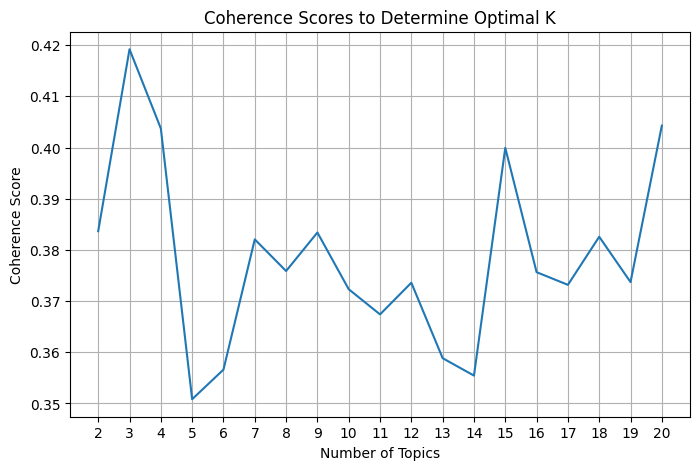

In [ ]:
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

# 1. Range of topics to evaluate
start = 2
limit = 21
step = 1
topic_range = range(start, limit, step)

coherence_scores = []

# 2. Loop through different numbers of topics
for k in topic_range:
    print(f"Training model with {k} topics...")

    # Increased passes to allow the model to converge properly
    lda_k = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=20 # Increased passes for better convergence and more reliable coherence
    )

    # Calculate Coherence Score
    coherence_model = CoherenceModel(
        model=lda_k,
        texts=processed_docs,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_score = coherence_model.get_coherence()
    coherence_scores.append(coherence_score)
    print(f"   Coherence Score: {coherence_score:.4f}")

# 3. Plot the results
x = topic_range
plt.figure(figsize=(8,5))
plt.plot(x, coherence_scores)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Coherence Scores to Determine Optimal K")
plt.xticks(x)
plt.grid(True)
plt.show()

## Updated LDA Model

In [ ]:
lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=7, #optimal number of topics
    random_state=42,
    passes=20
)

print("\n--- New Cleaned Topics ---")
for topic_id, topic_content in lda_model.print_topics(num_words=10):
    print(f"\nTopic #{topic_id+1}")
    print(topic_content)


--- New Cleaned Topics ---

Topic #1
0.030*"nov." + 0.021*"subsection" + 0.018*"homestead" + 0.018*"amended" + 0.013*"veterans" + 0.010*"subdivision" + 0.009*"assistance" + 0.009*"valorem" + 0.008*"development" + 0.008*"retirement"

Topic #2
0.017*"municipality" + 0.015*"fire" + 0.014*"indebtedness" + 0.013*"pledge" + 0.012*"facility" + 0.010*"effective" + 0.010*"issuance" + 0.009*"taxable" + 0.008*"valorem" + 0.007*"hereunder"

Topic #3
0.016*"effective" + 0.007*"initiative" + 0.007*"subdivision" + 0.007*"railroad" + 0.005*"indebtedness" + 0.005*"educational" + 0.005*"fiscal" + 0.005*"referendum" + 0.005*"village" + 0.004*"item"

Topic #4
0.024*"effective" + 0.019*"baltimore" + 0.010*"council" + 0.008*"valuation" + 0.007*"fiscal" + 0.007*"wednesday" + 0.006*"home" + 0.006*"recall" + 0.006*"chapter" + 0.006*"plantation"

Topic #5
0.031*"art" + 0.013*"commonwealth" + 0.012*"parish" + 0.008*"council" + 0.007*"superior" + 0.007*"numbering" + 0.005*"plea" + 0.005*"effective" + 0.005*"chan

# Visualizations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

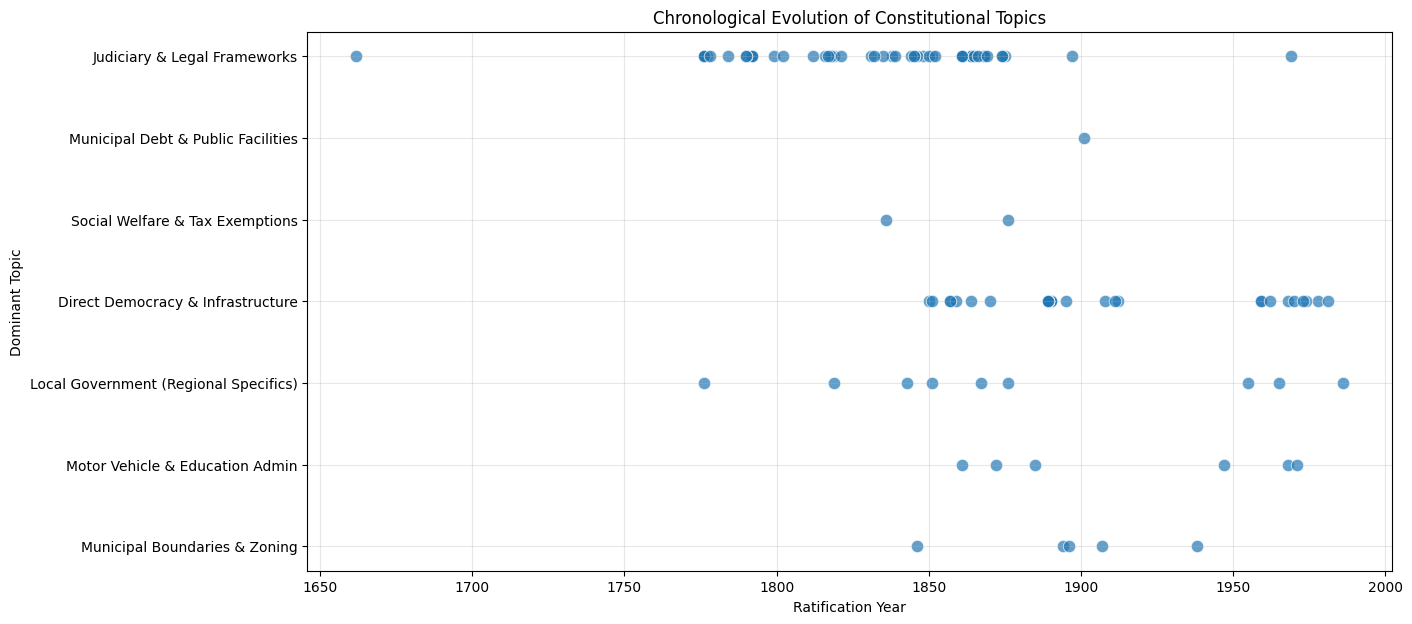

In [ ]:
# 1. Assign Dominant Topic to DataFrame (Run this with your FINAL LDA model)
dominant_topics = []
for i, row in enumerate(lda_model[corpus]):
    row = sorted(row, key=lambda x: x[1], reverse=True)
    dominant_topics.append(row[0][0]) # Get the topic ID with highest prob

df['Dominant_Topic'] = dominant_topics

# 2. Map Topic IDs to Names (Updated for 7 topics)
topic_labels = {
    0: "Social Welfare & Tax Exemptions",
    1: "Municipal Debt & Public Facilities",
    2: "Direct Democracy & Infrastructure",
    3: "Local Government (Regional Specifics)",
    4: "Judiciary & Legal Frameworks",
    5: "Motor Vehicle & Education Admin",
    6: "Municipal Boundaries & Zoning"
}

df['Topic_Label'] = df['Dominant_Topic'].map(topic_labels)

# 3. Plot: Dominant Topic vs. Year
plt.figure(figsize=(14, 7))
sns.scatterplot(data=df, x='Year', y='Topic_Label', alpha=0.7, s=80) # Removed hue='Region'
plt.title('Chronological Evolution of Constitutional Topics')
plt.xlabel('Ratification Year')
plt.ylabel('Dominant Topic')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import scipy.stats as stats

# 1. Prepare the Data
# We need a "Cross-Tabulation" (Count of documents for each Topic in each Decade)

# Create a 'Decade' column (bins the years into 10-year chunks)
# This prevents the test from having too many empty cells (e.g., only 1 doc in 1818)
df['Decade'] = (df['Year'] // 10) * 10

# Create the Contingency Table
# Rows = Decades, Columns = Topics
contingency_table = pd.crosstab(df['Decade'], df['Dominant_Topic'])

print("Contingency Table (Count of Topics per Decade):")
print(contingency_table)

# 2. Run Chi-Square Test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.2f}")
print(f"P-Value: {p:.4e}")

# 3. Interpretation
if p < 0.05:
    print("\nResult: The distribution of topics is DEPENDENT on the Decade.")
    print("The shift in topics over time is statistically significant.")
else:
    print("\nResult: Topics are independent of time. The distribution is random.")

Contingency Table (Count of Topics per Decade):
Dominant_Topic  0  1  2  3   4  5  6
Decade                              
1660            0  0  0  0   1  0  0
1770            0  0  0  1   8  0  0
1780            0  0  0  0   1  0  0
1790            0  0  0  0   6  0  0
1800            0  0  0  0   1  0  0
1810            0  0  0  1   6  0  0
1820            0  0  0  0   1  0  0
1830            1  0  0  0   5  0  0
1840            0  0  0  1   5  0  1
1850            0  0  5  1   3  0  0
1860            0  0  1  1  20  1  0
1870            1  0  1  1   3  1  0
1880            0  0  5  0   0  1  0
1890            0  0  4  0   1  0  2
1900            0  1  1  0   0  0  1
1910            0  0  2  0   0  0  0
1930            0  0  0  0   0  0  1
1940            0  0  0  0   0  1  0
1950            0  0  2  1   0  0  0
1960            0  0  2  1   1  1  0
1970            0  0  4  0   0  1  0
1980            0  0  1  1   0  0  0

Chi-Square Statistic: 205.25
P-Value: 1.0435e-05

Result: The d

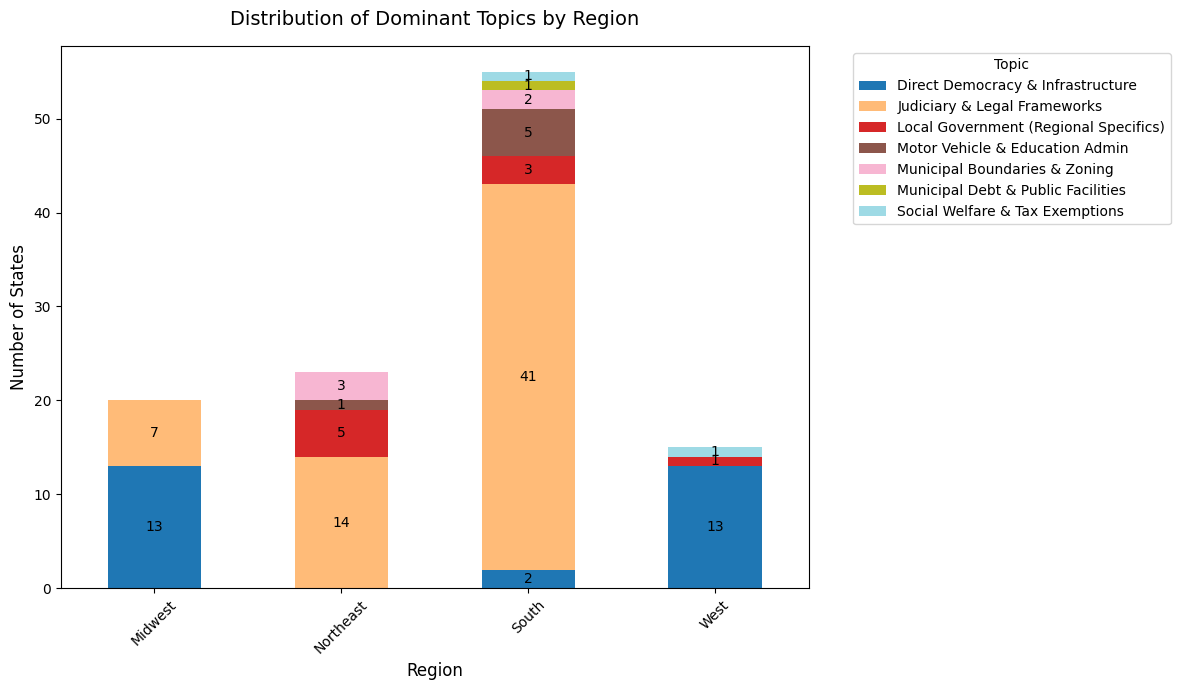

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create a Cross-Tabulation using the updated 7 topics
# Rows = Region, Columns = Topic Labels
topic_region_dist = pd.crosstab(df['Region'], df['Topic_Label'])

# 2. Plot as a Stacked Bar Chart
ax = topic_region_dist.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

plt.title('Distribution of Dominant Topics by Region', fontsize=14, pad=15)
plt.ylabel('Number of States', fontsize=12)
plt.xlabel('Region', fontsize=12)

# Explicitly move legend outside the plot
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Add count labels inside the bars for readability
for c in ax.containers:
    labels = [int(v.get_height()) if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center')

plt.tight_layout()
plt.show()

# Topic Evolution Over Time and Across Regions Simultaneously

To visualize how topics evolved over time and varied across different regions simultaneously, we can use a faceted plot. This plot shows the count of each dominant topic for every decade, with separate subplots for each region.

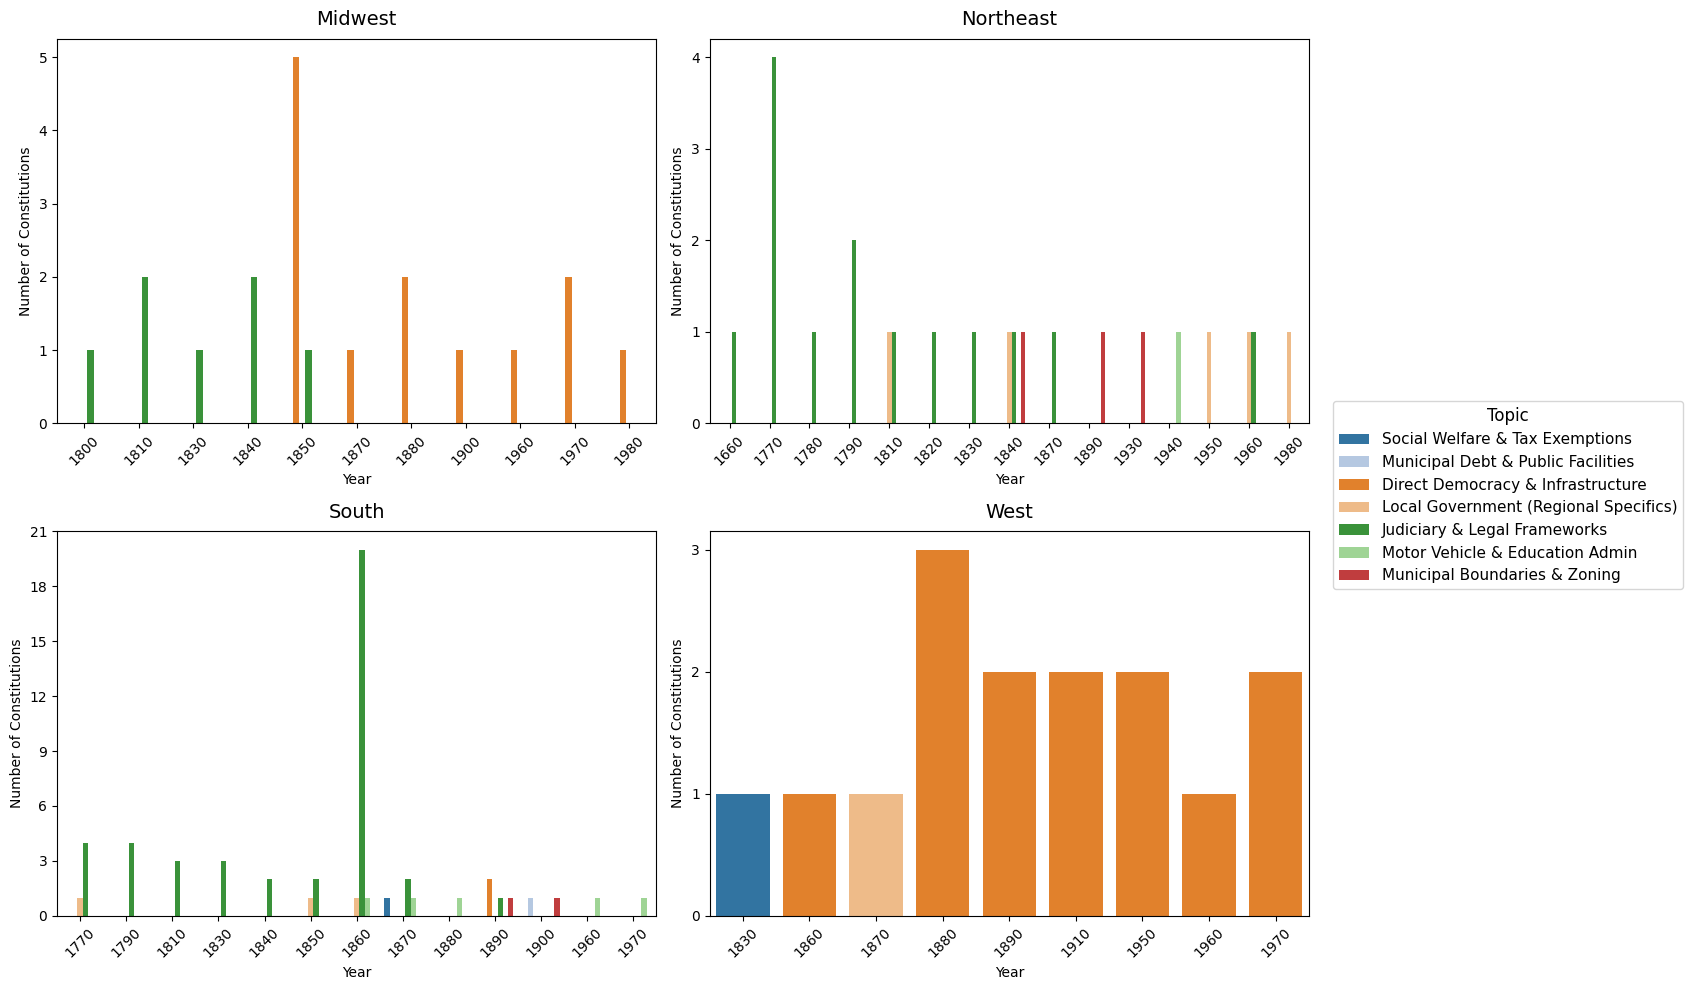

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator

# Ensure 'Topic_Label' is a categorical type for consistent ordering in plots
df['Topic_Label'] = pd.Categorical(df['Topic_Label'], categories=list(topic_labels.values()), ordered=True)

# Get the unique regions
regions = sorted(df['Region'].dropna().unique())

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Flatten the 2x2 array to easily loop over it

# Generate a separate graph for each region
for i, region in enumerate(regions):
    region_df = df[df['Region'] == region]

    ax = sns.countplot(
        data=region_df,
        x='Decade',
        hue='Topic_Label',
        palette='tab20',
        ax=axes[i]
    )

    axes[i].set_title(f'{region}', fontsize=14, pad=10)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Number of Constitutions')
    axes[i].tick_params(axis='x', rotation=45)

    # Force y-axis to use integer ticks
    axes[i].yaxis.set_major_locator(MaxNLocator(integer=True))

    # Remove the legend for each individual subplot
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

# Get handles and labels from the first subplot to create a single figure-level legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Topic", loc='center left', bbox_to_anchor=(0.95, 0.5), fontsize=11, title_fontsize=12)

# Adjust layout to make room for the unified legend
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()


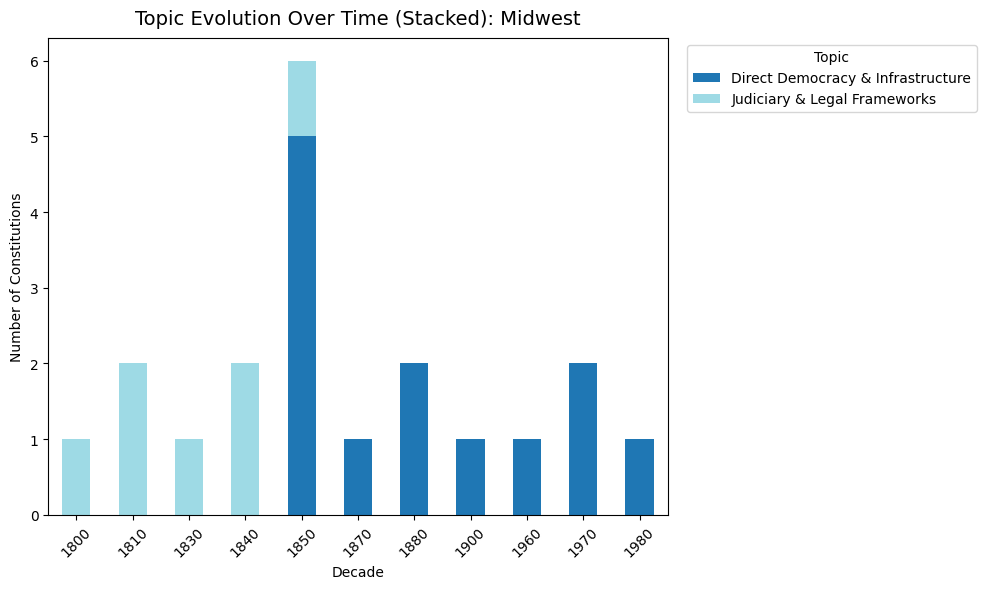

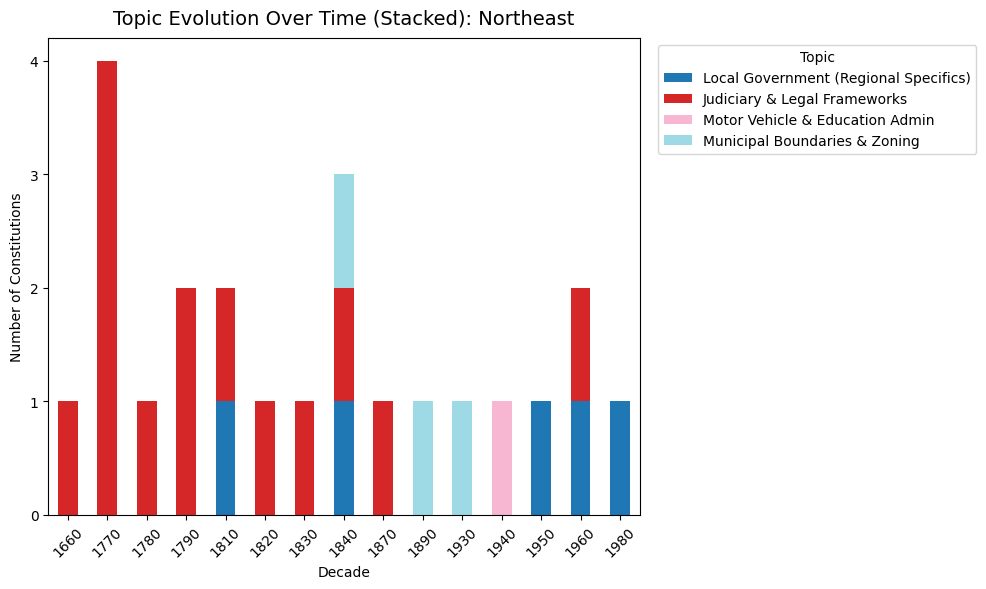

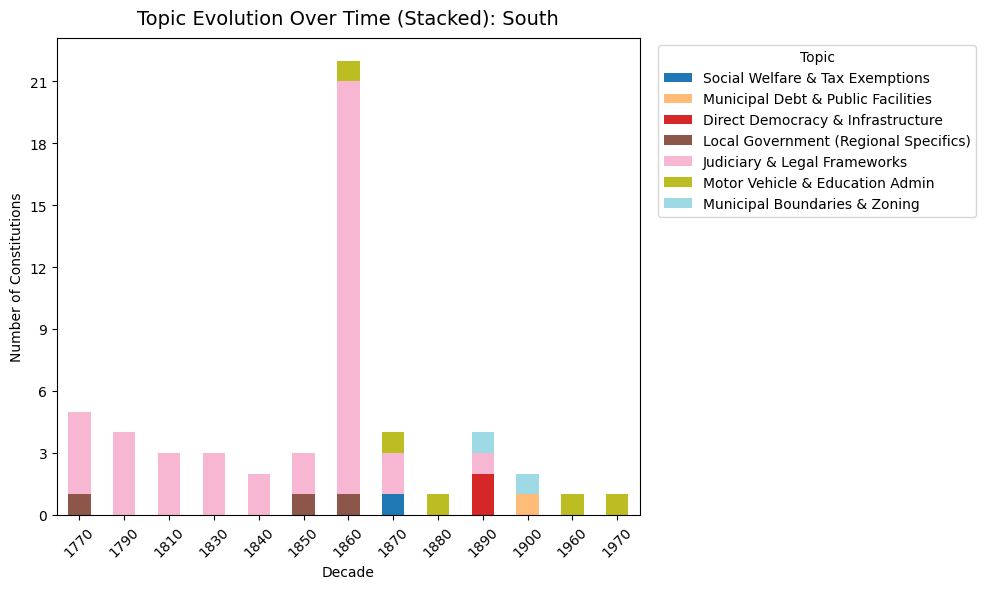

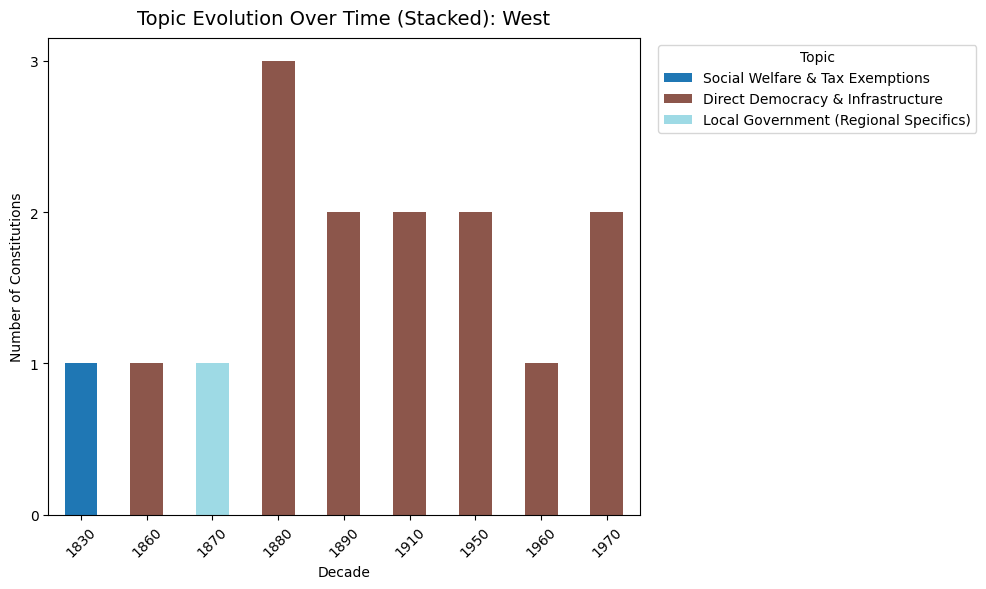

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

# Get the unique regions
regions = sorted(df['Region'].dropna().unique())

# Generate a stacked bar chart for each region
for region in regions:
    # Filter data for the specific region
    region_df = df[df['Region'] == region]

    # Create a cross-tabulation of Decade vs. Topic_Label
    crosstab = pd.crosstab(region_df['Decade'], region_df['Topic_Label'])

    # Plot stacked bar chart
    ax = crosstab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')

    plt.title(f'Topic Evolution Over Time (Stacked): {region}', fontsize=14, pad=10)
    plt.xlabel('Decade')
    plt.ylabel('Number of Constitutions')

    # Force y-axis to use integer ticks
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Place the legend outside the plot to prevent overlap
    plt.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Export Results For Further Analysis

In [ ]:
# 1. Extract topic probabilities for each document
topic_weights = []
for i, row in enumerate(lda_model[corpus]):
    # Initialize a dictionary with 0 for all topics
    topic_dict = {f'Topic_{j}': 0 for j in range(7)}
    # Update with actual probabilities
    for topic_num, prop_topic in row:
        topic_dict[f'Topic_{topic_num}'] = prop_topic
    topic_weights.append(topic_dict)

# 2. Convert to DataFrame and concatenate with original df
weights_df = pd.DataFrame(topic_weights)
df_with_weights = pd.concat([df, weights_df], axis=1)

# 3. Select columns to export
export_cols = ['State', 'Year', 'Region'] + [f'Topic_{j}' for j in range(7)]
export_df = df_with_weights[export_cols]

# 4. Export to CSV
export_df.to_csv('topic_weights.csv', index=False)

print("Topic weights exported successfully to 'topic_weights.csv'.")
display(export_df.head())

Topic weights exported successfully to 'topic_weights.csv'.


,State,Year,Region,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6
0,Alabama,1819,South,0.0,0.026075,0.000000,0.0,0.972090,0.0,0.0
1,Alabama,1861,South,0.0,0.000000,0.000000,0.0,0.997782,0.0,0.0
2,Alabama,1865,South,0.0,0.000000,0.000000,0.0,0.997016,0.0,0.0
3,Alabama,1868,South,0.0,0.261095,0.018444,0.0,0.719541,0.0,0.0
4,Alabama,1875,South,0.0,0.285031,0.196777,0.0,0.517635,0.0,0.0


In [ ]:
# Trigger the download of the CSV file
files.download('topic_weights.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Alternative Metrics: Perplexity and pyLDAvis
Let's evaluate the 7-topic model using Perplexity (a predictive metric) and pyLDAvis (a visual metric for topic distinctness).

In [ ]:
# 1. Calculate Model Perplexity
# Perplexity measures how well the model predicts new data. A lower score is better.
# Note: Gensim's log_perplexity returns a negative number, so more negative = lower/better.
perplexity = lda_model.log_perplexity(corpus)
print(f"Log Perplexity for 7-topic model: {perplexity:.4f}")

Log Perplexity for 7-topic model: -7.3078


In [ ]:
!pip install pyLDAvis

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import warnings

# Suppress deprecation warnings from pyLDAvis
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Enable visualization in the Colab notebook
pyLDAvis.enable_notebook()

# Prepare the visualization data
print("Generating interactive topic map...")
vis_data = gensimvis.prepare(lda_model, corpus, dictionary)

# Display the visualization
# Note: In the chart, check if the circles (topics) are well-separated or overlapping.
pyLDAvis.display(vis_data)

Generating interactive topic map...
